In [23]:
import pandas as pd

df = pd.read_csv("Superstore Sales Dataset.csv")

print(df.shape)

(9800, 18)


In [24]:
print(df[["Order Date", "Sales"]].head())

   Order Date     Sales
0  08/11/2017  261.9600
1  08/11/2017  731.9400
2  12/06/2017   14.6200
3  11/10/2016  957.5775
4  11/10/2016   22.3680


In [26]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

print(df["Order Date"].dtype)

datetime64[ns]


In [27]:
monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum()

print(monthly_sales)

Order Date
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040


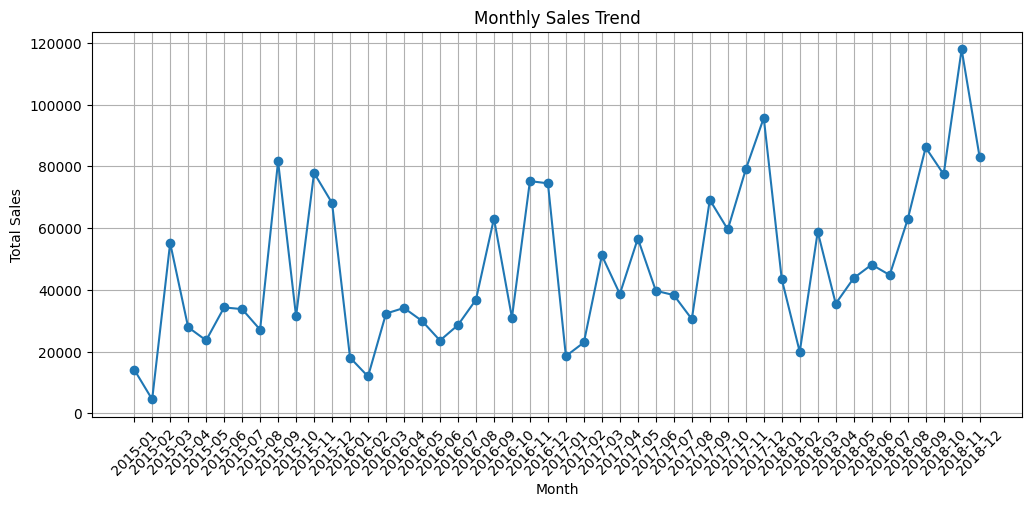

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [29]:
moving_average = monthly_sales.rolling(window=3).mean()

print(moving_average)

Order Date
2015-01             NaN
2015-02             NaN
2015-03    24643.798667
2015-04    29210.848000
2015-05    35585.651667
2015-06    28624.697867
2015-07    30582.927200
2015-08    31740.671700
2015-09    47507.535433
2015-10    46731.485433
2015-11    63661.526833
2015-12    59176.037400
2016-01    54713.892267
2016-02    32728.475700
2016-03    20785.895667
2016-04    26148.399300
2016-05    32151.105800
2016-06    29237.791000
2016-07    27389.054500
2016-08    29675.325067
2016-09    42853.402400
2016-10    43654.561900
2016-11    56464.914333
2016-12    60268.246067
2017-01    56111.830567
2017-02    38688.302400
2017-03    30895.455000
2017-04    37607.880333
2017-05    48833.911333
2017-06    45020.387000
2017-07    44900.725667
2017-08    36195.823100
2017-09    46018.791400
2017-10    53106.208067
2017-11    69280.973233
2017-12    78129.549933
2018-01    72760.696933
2018-02    53045.530800
2018-03    40753.628067
2018-04    38108.773433
2018-05    46077.101700
2018-

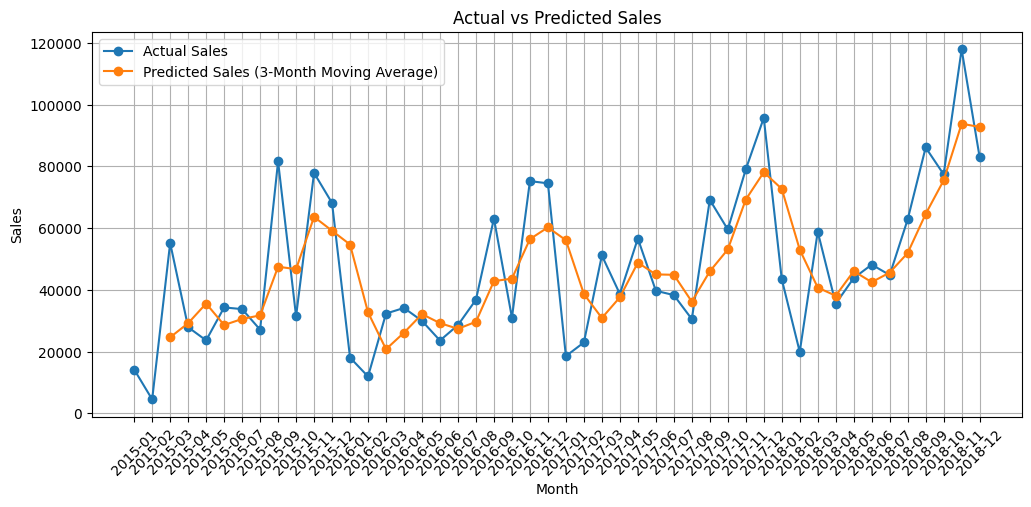

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values,
         label="Actual Sales", marker="o")

plt.plot(moving_average.index.astype(str), moving_average.values,
         label="Predicted Sales (3-Month Moving Average)", marker="o")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [31]:
predicted_sales = monthly_sales.shift(1).rolling(window=3).mean()

print(predicted_sales)

Order Date
2015-01             NaN
2015-02             NaN
2015-03             NaN
2015-04    24643.798667
2015-05    29210.848000
2015-06    35585.651667
2015-07    28624.697867
2015-08    30582.927200
2015-09    31740.671700
2015-10    47507.535433
2015-11    46731.485433
2015-12    63661.526833
2016-01    59176.037400
2016-02    54713.892267
2016-03    32728.475700
2016-04    20785.895667
2016-05    26148.399300
2016-06    32151.105800
2016-07    29237.791000
2016-08    27389.054500
2016-09    29675.325067
2016-10    42853.402400
2016-11    43654.561900
2016-12    56464.914333
2017-01    60268.246067
2017-02    56111.830567
2017-03    38688.302400
2017-04    30895.455000
2017-05    37607.880333
2017-06    48833.911333
2017-07    45020.387000
2017-08    44900.725667
2017-09    36195.823100
2017-10    46018.791400
2017-11    53106.208067
2017-12    69280.973233
2018-01    78129.549933
2018-02    72760.696933
2018-03    53045.530800
2018-04    40753.628067
2018-05    38108.773433
2018-

In [32]:
actual = monthly_sales.loc[predicted_sales.dropna().index]
predicted = predicted_sales.dropna()

mape = ((actual - predicted).abs() / actual).mean() * 100

print("MAPE:", round(mape, 2), "%")
print("Prediction Accuracy:", round(100 - mape, 2), "%")

MAPE: 50.58 %
Prediction Accuracy: 49.42 %


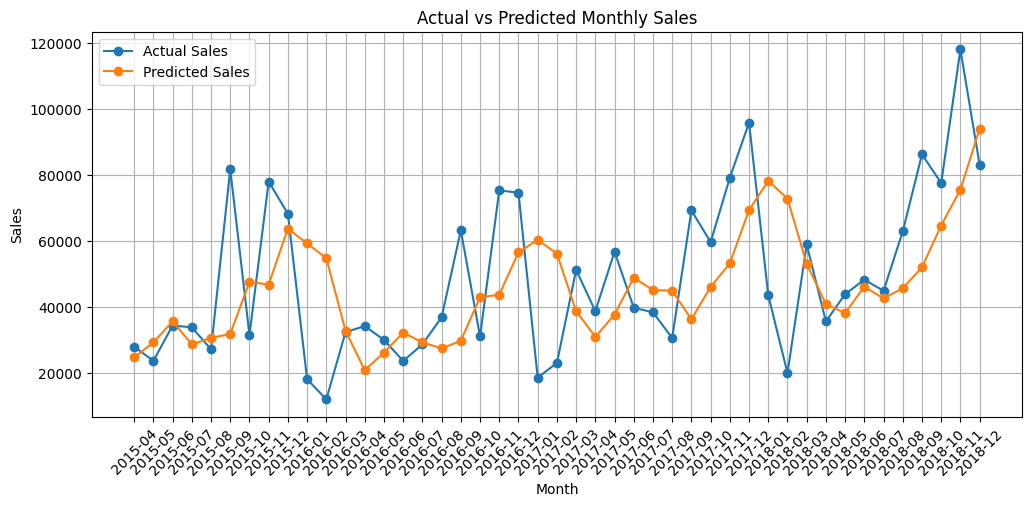

In [33]:
plt.figure(figsize=(12, 5))

plt.plot(actual.index.astype(str), actual.values,
         marker="o", label="Actual Sales")

plt.plot(predicted.index.astype(str), predicted.values,
         marker="o", label="Predicted Sales")

plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

## Final Observations

- Sales showed noticeable fluctuations from month to month.
- Overall sales trend increased toward the later years.
- The 3-month moving average captured the general sales direction but did not follow sudden sales spikes closely.
- The prediction accuracy using the 3-month moving average was **49.42%**.
- The simple moving-average method provides a basic prediction, but more advanced forecasting models could improve prediction accuracy.